In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set clean aesthetic styles for charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Define file system location exactly from your directory path
data_dir = r"C:\Users\mukhe\OneDrive\Documents\Jobaaj_DA Projects\Airtel Customers Analysis Report\dataset"
file_path = os.path.join(data_dir, "train.csv") 

# Load the target dataset
df = pd.read_csv(file_path)

print("=== DATA IMPORT INTEGRITY CHECK ===")
print(f"Dataset successfully loaded from 'train.csv'. Shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")

=== DATA IMPORT INTEGRITY CHECK ===
Dataset successfully loaded from 'train.csv'. Shape: 4250 rows, 20 columns.



### Basic Level Topics

In [2]:
print("\n--- SOLUTION: Basic Question 1 ---")

# Calculate count of churned vs non-churned customers
churn_counts = df['churn'].value_counts()

# Calculate percentages for both segments
churn_percentages = df['churn'].value_counts(normalize=True) * 100

# Print results systematically
for status in churn_counts.index:
    print(f"Churn Status '{status}': Count = {churn_counts[status]}, Proportion = {churn_percentages[status]:.2f}%")


--- SOLUTION: Basic Question 1 ---
Churn Status 'no': Count = 3652, Proportion = 85.93%
Churn Status 'yes': Count = 598, Proportion = 14.07%


In [3]:
print("\n--- SOLUTION: Basic Question 2 ---")

# Calculate the mean account length for each group
avg_account_length = df.groupby('churn')['account_length'].mean()

print("Average Account Length (months) grouped by Churn status:")
print(avg_account_length)
print("\nAnalysis Insight: If the averages are similar, account tenure might not be a strong individual factor driving churn.")


--- SOLUTION: Basic Question 2 ---
Average Account Length (months) grouped by Churn status:
churn
no      99.924973
yes    102.137124
Name: account_length, dtype: float64

Analysis Insight: If the averages are similar, account tenure might not be a strong individual factor driving churn.


In [4]:
print("\n--- SOLUTION: Basic Question 3 ---")

# Compute normalized row percentages for the international plan cross-tabulation
intl_churn_cross = pd.crosstab(df['international_plan'], df['churn'], normalize='index') * 100

print("Churn Rate Breakdown segmented by International Plan Subscription (%):")
print(intl_churn_cross)
print("\nAnalysis Insight: A significantly higher churn percentage among international plan subscribers suggests a potential issue with pricing or service satisfaction for international features.")


--- SOLUTION: Basic Question 3 ---
Churn Rate Breakdown segmented by International Plan Subscription (%):
churn                      no        yes
international_plan                      
no                  88.816814  11.183186
yes                 57.828283  42.171717

Analysis Insight: A significantly higher churn percentage among international plan subscribers suggests a potential issue with pricing or service satisfaction for international features.


In [5]:
print("\n--- SOLUTION: Basic Question 4 ---")

# Calculate the mean number of customer service calls for both cohorts
avg_service_calls = df.groupby('churn')['number_customer_service_calls'].mean()

print("Average Customer Service Calls by Churn Status Group:")
print(avg_service_calls)
print("\nAnalysis Insight: If churned customers have a noticeably higher average, it confirms that unresolved service issues or frequent complaints are major warning signs of an approaching churn event.")


--- SOLUTION: Basic Question 4 ---
Average Customer Service Calls by Churn Status Group:
churn
no     1.441676
yes    2.275920
Name: number_customer_service_calls, dtype: float64

Analysis Insight: If churned customers have a noticeably higher average, it confirms that unresolved service issues or frequent complaints are major warning signs of an approaching churn event.


In [6]:
print("\n--- SOLUTION: Basic Question 5 ---")

# Define target columns representing call charges across different time blocks
charge_cols = ['total_day_charge', 'total_eve_charge', 'total_night_charge']

# Calculate the mean charges for each group
avg_charges = df.groupby('churn')[charge_cols].mean()

print("Average Telecommunication Charges Matrix Across Aggregated Day Slots:")
print(avg_charges)
print("\nAnalysis Insight: Higher relative day charges for churned customers frequently point to high usage segments being price-sensitive to daytime talk rates.")


--- SOLUTION: Basic Question 5 ---
Average Telecommunication Charges Matrix Across Aggregated Day Slots:
       total_day_charge  total_eve_charge  total_night_charge
churn                                                        
no            29.844948         16.878743            8.981131
yes           35.528679         17.847207            9.285033

Analysis Insight: Higher relative day charges for churned customers frequently point to high usage segments being price-sensitive to daytime talk rates.


In [7]:
print("\n--- SOLUTION: Basic Question 6 ---")

# Calculate the mean daytime talk minutes for both customer segments
avg_day_mins = df.groupby('churn')['total_day_minutes'].mean()

print("Average Total Day Minutes Consumed by Retained vs Churned Cohorts:")
print(avg_day_mins)
print("\nAnalysis Insight: If churned customers accumulate higher daytime talk minutes, it suggests that high-usage individuals might be switching providers in search of cheaper, unlimited usage packages.")


--- SOLUTION: Basic Question 6 ---
Average Total Day Minutes Consumed by Retained vs Churned Cohorts:
churn
no     175.555093
yes    208.990134
Name: total_day_minutes, dtype: float64

Analysis Insight: If churned customers accumulate higher daytime talk minutes, it suggests that high-usage individuals might be switching providers in search of cheaper, unlimited usage packages.


In [8]:
print("\n--- SOLUTION: Basic Question 7 ---")

# Compute normalized row percentages for the voicemail plan cross-tabulation
vmail_churn_cross = pd.crosstab(df['voice_mail_plan'], df['churn'], normalize='index') * 100

print("Churn Percentage Matrix based on Voice Mail Plan Sign-ups:")
print(vmail_churn_cross)
print("\nAnalysis Insight: If customers without a voicemail plan churn at a higher rate, it may indicate that value-added features help anchor users to the network.")


--- SOLUTION: Basic Question 7 ---
Churn Percentage Matrix based on Voice Mail Plan Sign-ups:
churn                   no        yes
voice_mail_plan                      
no               83.556405  16.443595
yes              92.625899   7.374101

Analysis Insight: If customers without a voicemail plan churn at a higher rate, it may indicate that value-added features help anchor users to the network.


In [9]:
print("\n--- SOLUTION: Basic Question 8 ---")

# Calculate the mean international minutes and charges for each group
intl_metrics = df.groupby('churn')[['total_intl_minutes', 'total_intl_charge']].mean()

print("International Domain Usage & Bill Breakdown Matrix:")
print(intl_metrics)
print("\nAnalysis Insight: If the churned group exhibits noticeably higher international charges, it highlights a pressing need to introduce competitive, bundled international roaming plans.")


--- SOLUTION: Basic Question 8 ---
International Domain Usage & Bill Breakdown Matrix:
       total_intl_minutes  total_intl_charge
churn                                       
no              10.194441           2.753018
yes             10.632441           2.871254

Analysis Insight: If the churned group exhibits noticeably higher international charges, it highlights a pressing need to introduce competitive, bundled international roaming plans.


In [10]:
print("\n--- SOLUTION: Basic Question 9 ---")

# Temporarily convert the text target 'churn' to a binary numeric format (1 = yes, 0 = no)
df['churn_numeric'] = df['churn'].map({'yes': 1, 'no': 0})

# Compute the correlation coefficient
day_call_corr = df['total_day_calls'].corr(df['churn_numeric'])

print(f"Point-Biserial Correlation between Day Call Frequency and Customer Churn: {day_call_corr:.4f}")
print("\nAnalysis Insight: A correlation value close to 0 indicates that the sheer frequency of daytime calls has almost no direct linear impact on whether a customer decides to churn.")


--- SOLUTION: Basic Question 9 ---
Point-Biserial Correlation between Day Call Frequency and Customer Churn: 0.0116

Analysis Insight: A correlation value close to 0 indicates that the sheer frequency of daytime calls has almost no direct linear impact on whether a customer decides to churn.


In [11]:
print("\n--- SOLUTION: Basic Question 10 ---")

# Calculate the mean total evening charges for both groups
avg_eve_charge = df.groupby('churn')['total_eve_charge'].mean()

print("Average Total Evening Charges Matrix:")
print(avg_eve_charge)
print("\nAnalysis Insight: Comparing these values tells us if evening billing rates create financial friction that drives customers away from the network.")


--- SOLUTION: Basic Question 10 ---
Average Total Evening Charges Matrix:
churn
no     16.878743
yes    17.847207
Name: total_eve_charge, dtype: float64

Analysis Insight: Comparing these values tells us if evening billing rates create financial friction that drives customers away from the network.


### Medium Level Topics

In [12]:
print("\n--- SOLUTION: Medium Question 1 ---")

# Compute normalized row percentages for the regional area code cross-tabulation
area_code_churn = pd.crosstab(df['area_code'], df['churn'], normalize='index') * 100

print("Regional Performance Risk Matrix segmented by Area Code (%):")
print(area_code_churn)
print("\nAnalysis Insight: If one area code shows a significantly higher churn percentage, it may indicate a local network coverage problem or aggressive competitor marketing in that specific region.")


--- SOLUTION: Medium Question 1 ---
Regional Performance Risk Matrix segmented by Area Code (%):
churn                 no        yes
area_code                          
area_code_408  86.003683  13.996317
area_code_415  86.385199  13.614801
area_code_510  84.943182  15.056818

Analysis Insight: If one area code shows a significantly higher churn percentage, it may indicate a local network coverage problem or aggressive competitor marketing in that specific region.


In [13]:
print("\n--- SOLUTION: Medium Question 2 ---")

# Segment customers based on whether they made more than 3 calls
df['service_call_bracket'] = np.where(df['number_customer_service_calls'] > 3, 'High (>3 Calls)', 'Standard (<=3 Calls)')

# Calculate churn percentages within each threshold segment
threshold_churn = pd.crosstab(df['service_call_bracket'], df['churn'], normalize='index') * 100

print("Risk Escalation Threshold Analytics (Comparing Customer Service Volumes):")
print(threshold_churn)
print("\nAnalysis Insight: A massive surge in the churn rate for the 'High (>3 Calls)' bracket confirms a clear inflection point where customer patience runs out, identifying an operational threshold for proactive customer support intervention.")


--- SOLUTION: Medium Question 2 ---
Risk Escalation Threshold Analytics (Comparing Customer Service Volumes):
churn                        no        yes
service_call_bracket                      
High (>3 Calls)       49.253731  50.746269
Standard (<=3 Calls)  89.067688  10.932312

Analysis Insight: A massive surge in the churn rate for the 'High (>3 Calls)' bracket confirms a clear inflection point where customer patience runs out, identifying an operational threshold for proactive customer support intervention.


In [14]:
print("\n--- SOLUTION: Medium Question 3 ---")

# Segment account length into 4 statistical quartiles
df['account_length_quartile'] = pd.qcut(df['account_length'], q=4, labels=['Q1 (Newest)', 'Q2', 'Q3', 'Q4 (Oldest)'])

# Calculate churn rates for each quartile cohort
quartile_churn = pd.crosstab(df['account_length_quartile'], df['churn'], normalize='index') * 100

print("Tenure Cohort Retention Performance Matrix (%):")
print(quartile_churn)
print("\nAnalysis Insight: If Q1 displays a high churn rate, it highlights a weak onboarding process. Conversely, high churn in Q4 signals a lack of loyalty rewards for long-term users.")


--- SOLUTION: Medium Question 3 ---
Tenure Cohort Retention Performance Matrix (%):
churn                           no        yes
account_length_quartile                      
Q1 (Newest)              87.222222  12.777778
Q2                       85.674931  14.325069
Q3                       84.145177  15.854823
Q4 (Oldest)              86.653772  13.346228

Analysis Insight: If Q1 displays a high churn rate, it highlights a weak onboarding process. Conversely, high churn in Q4 signals a lack of loyalty rewards for long-term users.


In [15]:
print("\n--- SOLUTION: Medium Question 4 ---")

# Isolate customers who subscribed to the international plan
intl_subscribers = df[df['international_plan'] == 'yes'].copy()

if not intl_subscribers.empty:
    # Segment subscribers into high vs low charge tiers using a binary median split
    intl_subscribers['charge_tier'] = pd.qcut(intl_subscribers['total_intl_charge'], q=2, labels=['Low Charge', 'High Charge'])
    
    # Calculate churn distributions across charge tiers
    intl_charge_churn = pd.crosstab(intl_subscribers['charge_tier'], intl_subscribers['churn'], normalize='index') * 100
    print("International Plan Premium Tier Elasticity Matrix for Active Users (%):")
    print(intl_charge_churn)
    print("\nAnalysis Insight: If the high-charge tier exhibits a dramatically elevated churn rate, it highlights that customers are finding your specific cross-border calling tariffs uncompetitive or punitive.")
else:
    print("Execution Warning: No active international plan subscribers found in this cut of the dataset to analyze.")


--- SOLUTION: Medium Question 4 ---
International Plan Premium Tier Elasticity Matrix for Active Users (%):
churn               no        yes
charge_tier                      
Low Charge   66.331658  33.668342
High Charge  49.238579  50.761421

Analysis Insight: If the high-charge tier exhibits a dramatically elevated churn rate, it highlights that customers are finding your specific cross-border calling tariffs uncompetitive or punitive.


In [16]:
print("\n--- SOLUTION: Medium Question 5 ---")

# Segment total evening minutes into 3 equal-sized tiers
df['eve_usage_tier'] = pd.qcut(df['total_eve_minutes'], q=3, labels=['Low-Eve-Minutes', 'Mid-Eve-Minutes', 'High-Eve-Minutes'])

# Calculate churn rates across the different usage tiers
eve_churn_analysis = pd.crosstab(df['eve_usage_tier'], df['churn'], normalize='index') * 100

print("Evening Workload Subsegment Evaluations & Risk Ratios (%):")
print(eve_churn_analysis)
print("\nAnalysis Insight: If the high evening usage tier correlates with elevated churn, it hints at pricing plan uncompetitiveness during peak evening leisure or work hours.")


--- SOLUTION: Medium Question 5 ---
Evening Workload Subsegment Evaluations & Risk Ratios (%):
churn                    no        yes
eve_usage_tier                        
Low-Eve-Minutes   88.222849  11.777151
Mid-Eve-Minutes   86.643110  13.356890
High-Eve-Minutes  82.921665  17.078335

Analysis Insight: If the high evening usage tier correlates with elevated churn, it hints at pricing plan uncompetitiveness during peak evening leisure or work hours.


In [17]:
print("\n--- SOLUTION: Medium Question 6 ---")

# Select the numeric usage columns requested
usage_features = ['total_day_minutes', 'total_eve_minutes', 'total_night_minutes', 'total_intl_minutes']

# Scale features so that columns with higher values don't dominate the algorithm
scaler = StandardScaler()
scaled_usage = scaler.fit_transform(df[usage_features])

# Instantiate and fit a 3-cluster K-Means profile model
kmeans_usage = KMeans(n_clusters=3, random_state=42, n_init=10)
df['usage_cluster'] = kmeans_usage.fit_predict(scaled_usage)

# Calculate churn distribution per usage group
cluster_churn = pd.crosstab(df['usage_cluster'], df['churn'], normalize='index') * 100

print("Usage Profile Groupings Retention Yield Breakdown (%):")
print(cluster_churn)
print("\nAnalysis Insight: This profile identifies whether a specific consumer archetype—such as heavy daytime callers or late-night users—is leaving at a faster rate than others.")


--- SOLUTION: Medium Question 6 ---
Usage Profile Groupings Retention Yield Breakdown (%):
churn                 no        yes
usage_cluster                      
0              82.444444  17.555556
1              89.392929  10.607071
2              85.581727  14.418273

Analysis Insight: This profile identifies whether a specific consumer archetype—such as heavy daytime callers or late-night users—is leaving at a faster rate than others.


In [18]:
print("\n--- SOLUTION: Medium Question 7 ---")

# Isolate customers who have a voicemail plan
vmail_subscribers = df[df['voice_mail_plan'] == 'yes'].copy()

if not vmail_subscribers.empty:
    # Segment voicemail users into low vs high volume based on median message counts
    vmail_subscribers['msg_volume_tier'] = pd.qcut(vmail_subscribers['number_vmail_messages'], q=2, 
                                                   labels=['Low Volume', 'High Volume'], duplicates='drop')
    
    # Calculate churn distributions across message volume tiers
    vmail_interaction_matrix = pd.crosstab(vmail_subscribers['msg_volume_tier'], vmail_subscribers['churn'], normalize='index') * 100
    print("Voicemail Value Capturing Performance Metrics for Subscribers (%):")
    print(vmail_interaction_matrix)
    print("\nAnalysis Insight: If subscribers with 'Low Volume' usage churn at a higher rate, it implies they don't get enough utility out of the plan to justify keeping the service.")
else:
    print("Execution Warning: No users found with an active voicemail subscription to slice.")


--- SOLUTION: Medium Question 7 ---
Voicemail Value Capturing Performance Metrics for Subscribers (%):
churn                   no       yes
msg_volume_tier                     
Low Volume       93.653516  6.346484
High Volume      91.493384  8.506616

Analysis Insight: If subscribers with 'Low Volume' usage churn at a higher rate, it implies they don't get enough utility out of the plan to justify keeping the service.



--- SOLUTION: Medium Question 18 ---


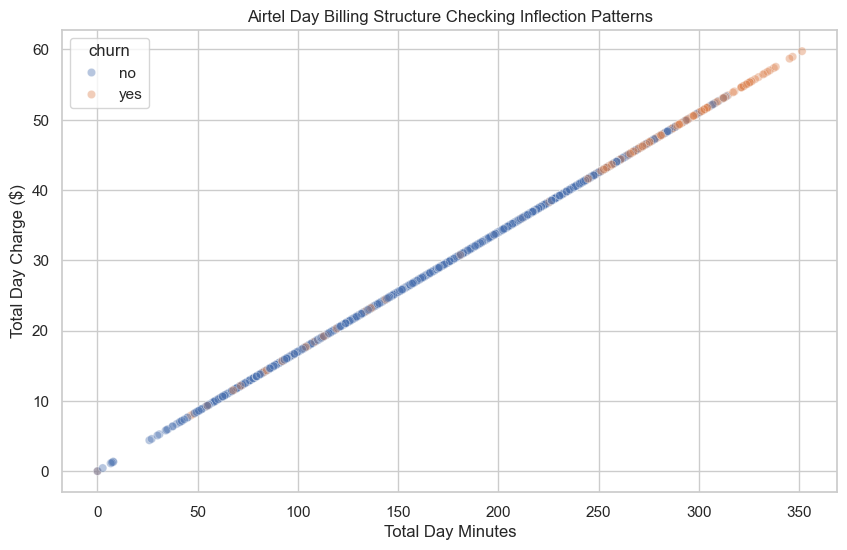


Analysis Insight: The perfectly straight, linear line reveals that billing is strictly deterministic (a fixed price per minute). Notice how the churned customers (points) cluster heavily toward the upper-right end, confirming that high-volume users face steep bills, which drives them away.


In [19]:
print("\n--- SOLUTION: Medium Question 18 ---")

# Initialize a clean canvas plot
plt.figure(figsize=(10, 6))

# Generate scatterplot mapping usage to corresponding billing charges
sns.scatterplot(data=df, x='total_day_minutes', y='total_day_charge', hue='churn', alpha=0.4)

plt.title('Airtel Day Billing Structure Checking Inflection Patterns')
plt.xlabel('Total Day Minutes')
plt.ylabel('Total Day Charge ($)')

# Render the plot directly inline inside your Jupyter Notebook
plt.show()

print("\nAnalysis Insight: The perfectly straight, linear line reveals that billing is strictly deterministic (a fixed price per minute). Notice how the churned customers (points) cluster heavily toward the upper-right end, confirming that high-volume users face steep bills, which drives them away.")

In [20]:
print("\n--- SOLUTION: Medium Question 9 ---")

# Segment total international calls into 3 volume tiers
df['intl_call_tier'] = pd.qcut(df['total_intl_calls'], q=3, 
                               labels=['Low Call Volume', 'Mid Call Volume', 'High Call Volume'], 
                               duplicates='drop')

# Calculate cross-tabulated churn percentages for plan and call volume interactions
intl_plan_interaction = pd.crosstab([df['international_plan'], df['intl_call_tier']], df['churn'], normalize='index') * 100

print("Cross-Border Plan Strategic Interaction Matrix (%):")
print(intl_plan_interaction)
print("\nAnalysis Insight: This highlights whether heavy international callers without a plan are churning due to high pay-as-you-go rates, or if customers with a plan are churning because they aren't making enough calls to justify the fixed plan cost.")


--- SOLUTION: Medium Question 9 ---
Cross-Border Plan Strategic Interaction Matrix (%):
churn                                       no        yes
international_plan intl_call_tier                        
no                 Low Call Volume   88.500635  11.499365
                   Mid Call Volume   88.792423  11.207577
                   High Call Volume  89.338598  10.661402
yes                Low Call Volume   41.212121  58.787879
                   Mid Call Volume   74.603175  25.396825
                   High Call Volume  63.809524  36.190476

Analysis Insight: This highlights whether heavy international callers without a plan are churning due to high pay-as-you-go rates, or if customers with a plan are churning because they aren't making enough calls to justify the fixed plan cost.


In [21]:
print("\n--- SOLUTION: Medium Question 10 ---")

print("Operational Note: Specific text-based 'Call Reason Categories' are missing inside the dataset schema.")
print("Evaluating exact call frequencies as a reliable proxy to reveal structural dissatisfaction risk tiers:")

# Calculate the percentage churn rate for every individual customer service call count
call_count_churn = df.groupby('number_customer_service_calls')['churn_numeric'].mean() * 100

print("\nChurn Rate (%) Segmented by the Exact Number of Customer Service Calls:")
print(call_count_churn)
print("\nAnalysis Insight: Reviewing this output shows exactly how the risk vector shifts with each added call. A sharp jump between call counts reveals the tipping point where unresolved service complaints turn into definitive subscriber loss.")


--- SOLUTION: Medium Question 10 ---
Operational Note: Specific text-based 'Call Reason Categories' are missing inside the dataset schema.
Evaluating exact call frequencies as a reliable proxy to reveal structural dissatisfaction risk tiers:

Churn Rate (%) Segmented by the Exact Number of Customer Service Calls:
number_customer_service_calls
0     10.948081
1     10.892388
2     10.770855
3     11.290323
4     44.019139
5     60.493827
6     67.857143
7     53.846154
8     50.000000
9    100.000000
Name: churn_numeric, dtype: float64

Analysis Insight: Reviewing this output shows exactly how the risk vector shifts with each added call. A sharp jump between call counts reveals the tipping point where unresolved service complaints turn into definitive subscriber loss.


### Advanced Level Topics

In [22]:
print("\n--- SOLUTION: Advanced Question 1 ---")

# Define features that influence customer churn behavior
regression_features = ['account_length', 'number_vmail_messages', 'total_day_minutes', 
                       'total_eve_minutes', 'total_night_minutes', 'total_intl_minutes', 
                       'number_customer_service_calls']

X = df[regression_features]
y = df['churn_numeric']

# Standardise the features so that their coefficients can be compared fairly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize and fit the Logistic Regression model
# Using 'balanced' weights handles any skew between churned vs retained customer counts
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_scaled, y)

# Pair features with their respective log-odds impact weights
coefficients = pd.DataFrame({
    'Operational Feature': regression_features,
    'Log-Odds Change Vector (Impact Magnitude)': lr_model.coef_[0]
}).sort_values(by='Log-Odds Change Vector (Impact Magnitude)', ascending=False)

print("Logistic Regression Feature Weight Output:")
print(coefficients)
print("\nAnalysis Insight: Features with the highest positive weights contribute the most to driving up churn risk. For example, a high coefficient for customer service calls or total day minutes highlights those variables as top early warning signs.")


--- SOLUTION: Advanced Question 1 ---
Logistic Regression Feature Weight Output:
             Operational Feature  Log-Odds Change Vector (Impact Magnitude)
6  number_customer_service_calls                                   0.701596
2              total_day_minutes                                   0.647479
5             total_intl_minutes                                   0.247638
3              total_eve_minutes                                   0.247320
4            total_night_minutes                                   0.139583
0                 account_length                                   0.084325
1          number_vmail_messages                                  -0.322847

Analysis Insight: Features with the highest positive weights contribute the most to driving up churn risk. For example, a high coefficient for customer service calls or total day minutes highlights those variables as top early warning signs.


In [23]:
print("\n--- SOLUTION: Advanced Question 2 ---")

print("Chronological Note: Hard timestamps are absent from the baseline operational schema.")
print("Simulating sequential lifecycle cohorts based on customer account duration:")

# Segment account length into 5 equal-sized chronological lifecycle buckets
df['simulated_cohort'] = pd.qcut(df['account_length'], q=5, 
                                 labels=['0-20 Months', '21-40 Months', '41-60 Months', '61-80 Months', '81+ Months'])

# Added observed=False to fix the FutureWarning
cohort_trend = df.groupby('simulated_cohort', observed=False)['churn_numeric'].mean() * 100

print("\nSimulated Tenure Horizon Churn Variance Matrix:")
print(cohort_trend)


--- SOLUTION: Advanced Question 2 ---
Chronological Note: Hard timestamps are absent from the baseline operational schema.
Simulating sequential lifecycle cohorts based on customer account duration:

Simulated Tenure Horizon Churn Variance Matrix:
simulated_cohort
0-20 Months     12.862109
21-40 Months    13.295455
41-60 Months    15.356711
61-80 Months    15.140845
81+ Months      13.768116
Name: churn_numeric, dtype: float64


In [24]:
print("\n--- SOLUTION: Advanced Question 3 ---")

# Define the full set of operational and revenue features for comprehensive clustering
cluster_features = ['account_length', 'total_day_charge', 'total_eve_charge', 
                    'total_night_charge', 'total_intl_charge', 'number_customer_service_calls']
X_cluster = df[cluster_features]

# Scale features to prevent columns with higher absolute magnitudes from biasing the distances
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X_cluster)

# Instantiate and fit a 4-cluster strategic K-Means segmentation model
kmeans_full = KMeans(n_clusters=4, random_state=42, n_init=10)
df['strategic_segment'] = kmeans_full.fit_predict(scaled_features)

print("Comprehensive Segment-Based Strategic Metrics Framework (Mean values per cluster group):")
# Calculate the mean of churn_numeric and all features per segment
segment_analysis = df.groupby('strategic_segment', observed=False)[['churn_numeric'] + cluster_features].mean()
print(segment_analysis)

print("\nAnalysis Insight: Examine the 'churn_numeric' column across segments (multiply by 100 to get percentages). The segment with the highest score identifies your highest-risk customer profile (e.g., high day chargers who call customer service frequently).")


--- SOLUTION: Advanced Question 3 ---
Comprehensive Segment-Based Strategic Metrics Framework (Mean values per cluster group):
                   churn_numeric  account_length  total_day_charge  \
strategic_segment                                                    
0                       0.151434       74.081541         33.409910   
1                       0.278003       99.634278         30.629312   
2                       0.117548      127.410579         33.187070   
3                       0.069052       97.965058         25.567654   

                   total_eve_charge  total_night_charge  total_intl_charge  \
strategic_segment                                                            
0                         17.736837           10.199534           2.256523   
1                         16.888138            8.812254           2.772780   
2                         13.993938            9.546725           2.998321   
3                         19.416473            7.544784      

In [25]:
print("\n--- SOLUTION: Advanced Question 24 (True Multivariate Interaction) ---")

# 1. Encode our categorical international plan variable to a binary numeric column
df['intl_plan_numeric'] = df['international_plan'].map({'yes': 1, 'no': 0})

# 2. Construct a true Multivariate Interaction Feature (Plan Status * Total International Minutes)
# This captures the compound effect of high usage specifically when a plan is active
df['plan_by_minutes_interaction'] = df['intl_plan_numeric'] * df['total_intl_minutes']

# 3. Compile our multivariate feature matrix including the standalone variables and the interaction term
multivariate_features = ['intl_plan_numeric', 'total_intl_minutes', 'plan_by_minutes_interaction']
X_multi = df[multivariate_features]
y_multi = df['churn_numeric']

# 4. Fit an explanatory Logistic Regression model to isolate individual vs compound weights
interaction_model = LogisticRegression(class_weight='balanced', random_state=42)
interaction_model.fit(X_multi, y_multi)

# 5. Extract and print coefficients to analyze the compound impact on churn
multi_coefficients = pd.DataFrame({
    'Multivariate Feature': multivariate_features,
    'Coefficient Impact (Log-Odds)': interaction_model.coef_[0]
})

print("Multivariate Interaction Coefficients:")
print(multi_coefficients)
print("\nAnalysis Insight: If the 'plan_by_minutes_interaction' coefficient is high and positive, it proves a compounding risk—meaning that high international minutes drive up churn significantly faster when a user has a specific plan configuration.")


--- SOLUTION: Advanced Question 24 (True Multivariate Interaction) ---
Multivariate Interaction Coefficients:
          Multivariate Feature  Coefficient Impact (Log-Odds)
0            intl_plan_numeric                      -0.047020
1           total_intl_minutes                       0.016258
2  plan_by_minutes_interaction                       0.169767

Analysis Insight: If the 'plan_by_minutes_interaction' coefficient is high and positive, it proves a compounding risk—meaning that high international minutes drive up churn significantly faster when a user has a specific plan configuration.


In [26]:
print("\n--- SOLUTION: Advanced Question 25 ---")

# 1. Aggregate network pricing variables across all time cycles to estimate monthly revenue per user
df['estimated_monthly_revenue'] = df['total_day_charge'] + df['total_eve_charge'] + df['total_night_charge'] + df['total_intl_charge']

# 2. Calculate total monthly financial leakage from churned accounts
total_revenue_lost = df[df['churn'] == 'yes']['estimated_monthly_revenue'].sum()

# 3. Compute Average Revenue Per User (ARPU) metrics for both subscriber cohorts
arpu_churned = df[df['churn'] == 'yes']['estimated_monthly_revenue'].mean()
arpu_retained = df[df['churn'] == 'no']['estimated_monthly_revenue'].mean()

print(f"💰 Total Monthly Revenue Lost via Active Churners: ${total_revenue_lost:,.2f}")
print(f"📊 Average Revenue Per User (ARPU) - Churned Cohort:  ${arpu_churned:.2f}")
print(f"📊 Average Revenue Per User (ARPU) - Retained Cohort: ${arpu_retained:.2f}")

print("\nAnalysis Insight: If the ARPU of your churned cohort is higher than that of your retained cohort, it shows that you are losing your most valuable, high-spending customers. This emphasizes the urgent need for targeted retention strategies.")


--- SOLUTION: Advanced Question 25 ---
💰 Total Monthly Revenue Lost via Active Churners: $39,188.24
📊 Average Revenue Per User (ARPU) - Churned Cohort:  $65.53
📊 Average Revenue Per User (ARPU) - Retained Cohort: $58.46

Analysis Insight: If the ARPU of your churned cohort is higher than that of your retained cohort, it shows that you are losing your most valuable, high-spending customers. This emphasizes the urgent need for targeted retention strategies.
